## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [3]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_pareto_2d
from ml_moo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42
#seed = 13

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=2,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([0.5, 0.5]))

### MOLA

00:59:26 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}


00:59:26 | DEBUG | ml_moo | Finding 1th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:26 | DEBUG | ml_moo | Finding 2th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/p

new solution added [0.61283158 0.61719796]
new solution added [0.61351914 0.61673736]
new solution added [0.61314523 0.61691569]
new solution added [0.6124682  0.61810826]
solution dominated [0.61260705 0.6189783 ]


00:59:26 | DEBUG | ml_moo | Calculated weights: [0.71590495 0.28409505]
00:59:26 | DEBUG | ml_moo | Importance: 0.0002667699897628273
00:59:26 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61662356]
00:59:26 | DEBUG | ml_moo | Iteration 5
00:59:26 | DEBUG | ml_moo | Solutions list: [array([0.6124682 , 0.61810826]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719796]), array([0.61452791, 0.61662356])]
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_re

new solution added [0.61259291 0.61760046]
new solution added [0.61296642 0.61705222]
new solution added [0.61271151 0.61736083]
new solution added [0.61335327 0.6168015 ]


...

00:59:29 | DEBUG | ml_moo | Calculated weights: [0.20222005 0.79777995]
00:59:29 | DEBUG | ml_moo | Importance: 5.186275304817911e-05
00:59:29 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
00:59:29 | DEBUG | ml_moo | Iteration 47
00:59:29 | DEBUG | ml_moo | Solutions list: [array([0.61316505, 0.61690248]), array([0.61251148, 0.61786278]), array([0.61252751, 0.61779913]), array([0.61252751, 0.61779913]), array([0.6125276, 0.6177988]), array([0.61252759, 0.61779884]), array([0.61253096, 0.61778645]), array([0.61254078, 0.6177521 ]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252432, 0.61781115]), array([0.61254082, 0.61775195]), array([0.613

new solution added [0.61369688 0.61668211]
new solution added [0.6137342  0.61667299]


00:59:30 | DEBUG | ml_moo | Calculated weights: [0.19097401 0.80902599]
00:59:30 | DEBUG | ml_moo | Importance: 5.150202804071746e-05
00:59:30 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
00:59:30 | DEBUG | ml_moo | Iteration 49
00:59:30 | DEBUG | ml_moo | Solutions list: [array([0.6137342 , 0.61667299]), array([0.61369688, 0.61668211]), array([0.61316505, 0.61690248]), array([0.61251148, 0.61786278]), array([0.61252751, 0.61779913]), array([0.61252751, 0.61779913]), array([0.6125276, 0.6177988]), array([0.61252759, 0.61779884]), array([0.61253096, 0.61778645]), array([0.61254078, 0.6177521 ]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.612

new solution added [0.61373435 0.61667295]
new solution added [0.61373418 0.61667299]


00:59:30 | DEBUG | ml_moo | Calculated weights: [0.19097401 0.80902599]
00:59:30 | DEBUG | ml_moo | Importance: 5.150202804071746e-05
00:59:30 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]


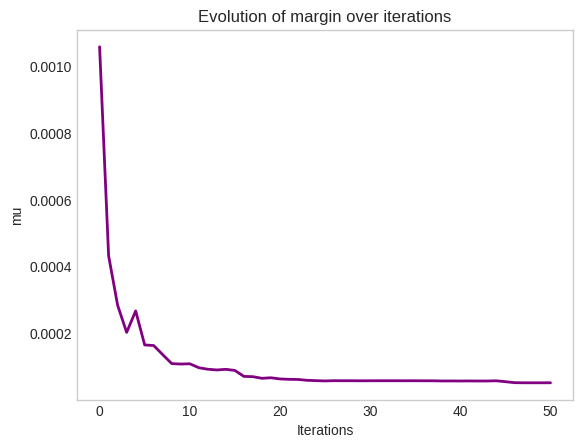

00:59:30 | INFO | ml_moo | Fit runtime: 4.00 seconds


In [9]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

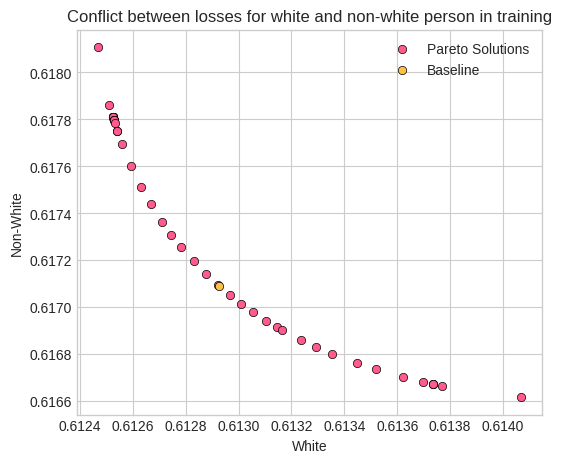

In [10]:
title="Conflict between losses for white and non-white person in training"
plot_pareto_2d(objectives=objs, 
               labels=("White", "Non-White"), 
               title=title,
               point=equal.objs,
               color="#FF5C8D"
               )

00:59:30 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
00:59:30 | DEBUG | ml_moo | Finding 1th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:30 | DEBUG | ml_moo | Finding 2th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

new solution added [0.61283158 0.61719796]
new solution added [0.61351914 0.61673736]
new solution added [0.61314523 0.61691569]
new solution added [0.6124682  0.61810826]
solution dominated [0.61260705 0.6189783 ]


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:30 | DEBUG | ml_moo | Calculated weights: [0.47367665 0.52632335]
00:59:30 | DEBUG | ml_moo | Importance: 0.0001648606693028798
00:59:30 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61662356]
00:59:30 | DEBUG | ml_moo | Iteration 6
00:59:30 | DEBUG | ml_moo | Solutions list: [array([0.61259291, 0.61760046]), array([0.6124682 , 0.61810826]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.617197

new solution added [0.61259291 0.61760046]
new solution added [0.61296642 0.61705222]
new solution added [0.61271151 0.61736083]
new solution added [0.61335327 0.6168015 ]
new solution added [0.6125245  0.61781049]


00:59:30 | DEBUG | ml_moo | Calculated weights: [0.10138697 0.89861303]
00:59:30 | DEBUG | ml_moo | Importance: 0.00010760382993835194
00:59:30 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61662356]
00:59:30 | DEBUG | ml_moo | Iteration 10
00:59:30 | DEBUG | ml_moo | Solutions list: [array([0.6125245 , 0.61781049]), array([0.61335327, 0.6168015 ]), array([0.61271151, 0.61736083]), array([0.61296642, 0.61705222]), array([0.61259291, 0.61760046]), array([0.6124682 , 0.61810826]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719796]), array([0.61452791, 0.61662356])]
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer

...

00:59:33 | DEBUG | ml_moo | Calculated weights: [0.38423578 0.61576422]
00:59:33 | DEBUG | ml_moo | Importance: 5.4794348398612414e-05
00:59:33 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
00:59:33 | DEBUG | ml_moo | Iteration 46
00:59:33 | DEBUG | ml_moo | Solutions list: [array([0.61251148, 0.61786278]), array([0.61252751, 0.61779913]), array([0.61252751, 0.61779913]), array([0.6125276, 0.6177988]), array([0.61252759, 0.61779884]), array([0.61253096, 0.61778645]), array([0.61254078, 0.6177521 ]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252429, 0.61781124]), array([0.61252432, 0.61781115]), array([0.61254082, 0.61775195]), array([0.61310419, 0.61694278]), array([0.61

new solution added [0.61316505 0.61690248]
new solution added [0.61369688 0.61668211]
new solution added [0.6137342  0.61667299]


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:34 | DEBUG | ml_moo | Calculated weights: [0.19097401 0.80902599]
00:59:34 | DEBUG | ml_moo | Importance: 5.150202804071746e-05
00:59:34 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]
00:59:34 | DEBUG | ml_moo | Iteration 49
00:59:34 | DEBUG | ml_moo | Solutions list: [array([0.6137342 , 0.61667299]), array([0.61369688, 0.61668211]), array([0.61316505, 0.61690248]), array([0.61251148, 0.61786278]), array([0.61252751, 0.61779

new solution added [0.61373435 0.61667295]
new solution added [0.61373418 0.61667299]


00:59:34 | DEBUG | ml_moo | Calculated weights: [0.19097401 0.80902599]
00:59:34 | DEBUG | ml_moo | Importance: 5.150202804071746e-05
00:59:34 | DEBUG | ml_moo | Global lower bound (y*): [0.6124682  0.61661664]


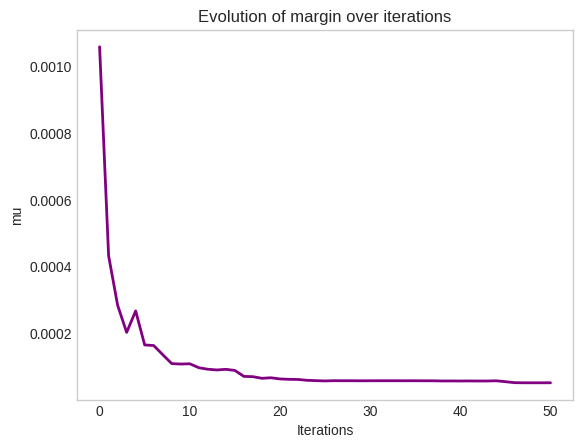

00:59:34 | INFO | ml_moo | Fit runtime: 3.87 seconds


In [11]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

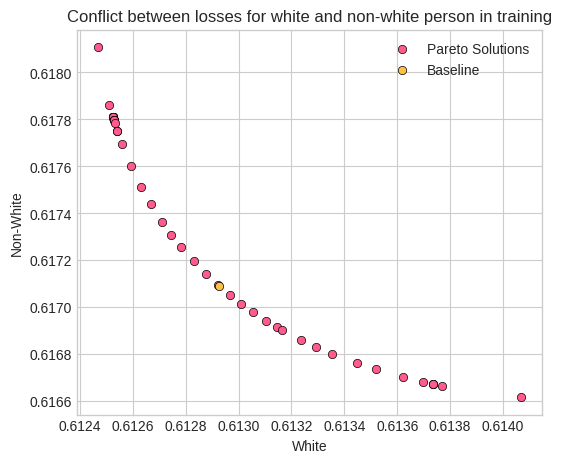

In [12]:
title="Conflict between losses for white and non-white person in training"
plot_pareto_2d(objectives=objs, 
               labels=("White", "Non-White"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D"
               )

### MONISE

In [13]:
scalarization = None
moopt = None
objs = None

In [14]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

00:59:34 | DEBUG | ml_moo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 50, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
00:59:34 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:34 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):


monise


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:35 | DEBUG | ml_moo.moo.monise | 3th solution - importance: 1.0
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the docum

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:35 | DEBUG | ml_moo.moo.monise | 11th solution - importance: 0.07721777363962883
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also r

...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:38 | DEBUG | ml_moo.moo.monise | 48th solution - importance: 0.0014880426935546794
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:38 | DEBUG | ml_moo.moo.monise | 50th solution - importance: 0.0014881372211091287


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [15]:
scalarization = None
moopt = None
objs = None

### Ramdon Weighted Sum

In [16]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

00:59:38 | WARNING | ml_moo | Ignored parameters for random_weights: {'targetGap', 'nodeTimeLimit', 'nodeGap'}
00:59:38 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
00:59:38 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
00:59:38 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [17]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

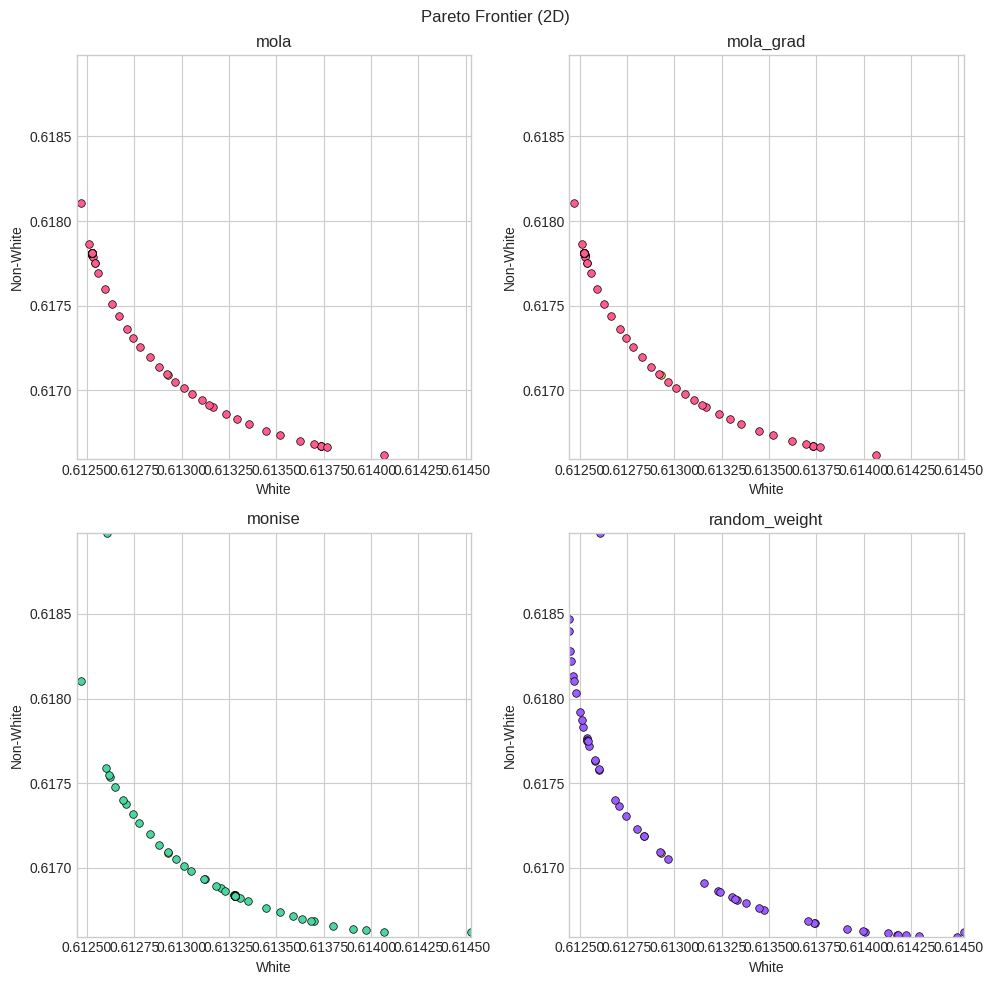

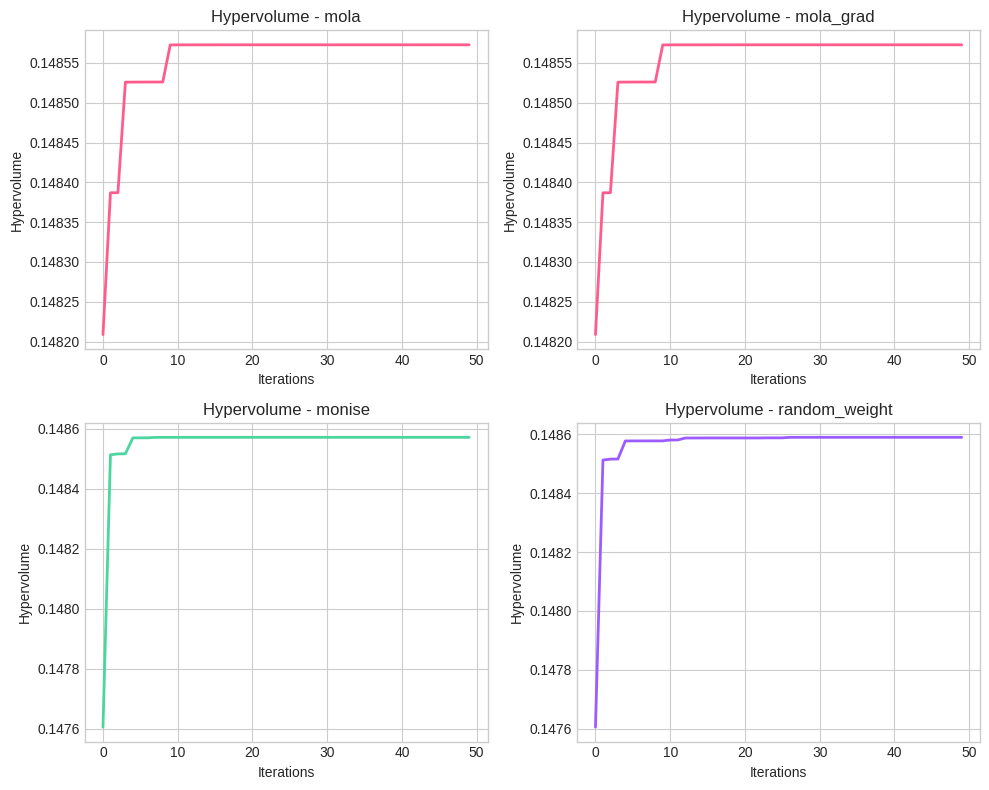

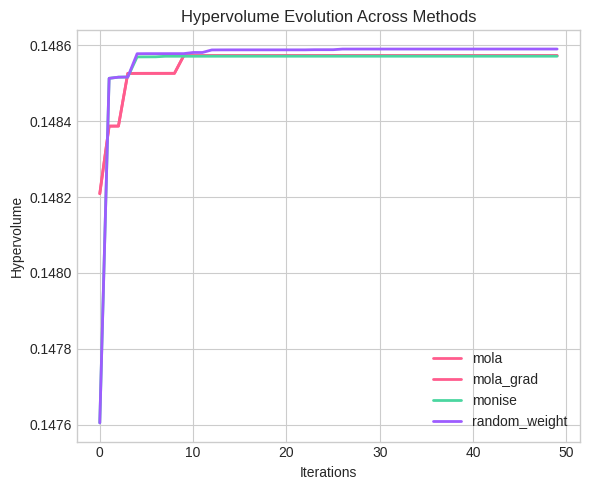

[Analyzer] Visualization complete.


In [18]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["White", "Non-White"]

Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs,
                      axis_label=axis_label,
                      )

In [19]:
from sklearn.metrics import accuracy_score
from ml_moo import run_ensemble

In [20]:
lambd = math.exp(-100)
clf = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
#predprob = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, pred)

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
#Logistic Regression Single Objctive
print(f'Logistic Regression Accuracy: {accuracy:.4f}')

Logistic Regression Accuracy: 0.6721


In [22]:
ensembles = {}
for method in results.keys():
    ensembles[method] = {
        'acc_voting'   : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='voting'),
        'acc_baggin'   : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='baggin'),
        'acc_adaboost' : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='adaboost')
    }

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

In [23]:
for method, ensemble in ensembles.items():
    print(f'\nMethod {method.upper()}')
    print(f'  Voting Accuracy:   {ensemble["acc_voting"]:.4f}')
    print(f'  Bagging Accuracy:  {ensemble["acc_baggin"]:.4f}')
    print(f'  Adaboost Accuracy: {ensemble["acc_adaboost"]:.4f}')


Method MOLA
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6730
  Adaboost Accuracy: 0.6721

Method MOLA_GRAD
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6679
  Adaboost Accuracy: 0.6721

Method MONISE
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6711
  Adaboost Accuracy: 0.6721

Method RANDOM_WEIGHT
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6692
  Adaboost Accuracy: 0.6721
